In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.fft
rcParams.update({'figure.autolayout': True})
import os
import IPython


In [ ]:

def f(x):
    return np.exp(-50 * (x - 0.5)**2)

#solution to 1a
def F_analytic(k):
    return np.sqrt(np.pi/50.0) * np.exp(-k**2 / 200.0) * np.exp(-1j * k / 2)

def dft_forward(xn):
    N = len(xn)
    Xk = np.zeros(N, dtype=complex)
    for k in range(N):
        temp = 0.0 + 0.0j
        for n in range(N):
            temp += xn[n] * np.exp(-2j * np.pi * k * n / N)
        Xk[k] = temp
    return Xk


def dft_inverse(Xk):
    N = len(Xk)
    xn = np.zeros(N, dtype=complex)

    for n in range(N):
        temp = 0.0 + 0.0j
        for k in range(N):
            temp += Xk[k] * np.exp(2j * np.pi * k * n / N)
        xn[n] = temp / N
    return xn

In [12]:
N = 8
x = np.linspace(0, 1, N, endpoint=False)
xn = np.exp(-50 * (x - 0.5)**2)

Xk = dft_forward(xn)
xn_back = dft_inverse(Xk)

print(np.allclose(xn, xn_back))

True


In [22]:
#sum points
L = 1.0
N_values = [128, 64, 32]
x = np.linspace(0.0, L, N, endpoint=False)
dx = x[1] - x[0]
xn = f(x)

In [23]:
#define K space
def k_grid(N, L=1.0):
    m = np.arange(N)
    freq = np.where(m < N//2, m, m - N) / L #sort into K space
    return 2.0 * np.pi * freq

k = k_grid(N, L)
Xk = dft_forward(xn)
F_num = dx * Xk

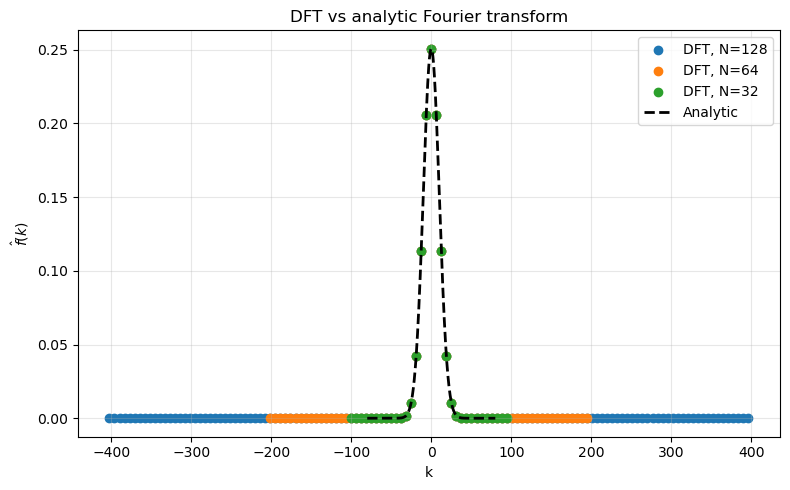

In [ ]:
plt.figure(figsize=(8, 5))

for N in N_values:
    x = np.linspace(0.0, L, N, endpoint=False)
    dx = x[1] - x[0]
    xn = f(x)

    Xk = dft_forward(xn)
    k = k_grid(N, L)
    F_num = dx * Xk

    idx = np.argsort(k)
    plt.scatter(k[idx], np.abs(F_num[idx]), label=f'DFT, N={N}')

# analytic curve on a dense k-grid
k_dense = np.linspace(-80, 80, 2000)
plt.plot(k_dense, np.abs(F_analytic(k_dense)), 'k--', linewidth=2, label='Analytic')

plt.xlabel('k')
plt.ylabel(r'$\hat{f}(k)$')
plt.title('DFT vs analytic Fourier transform')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

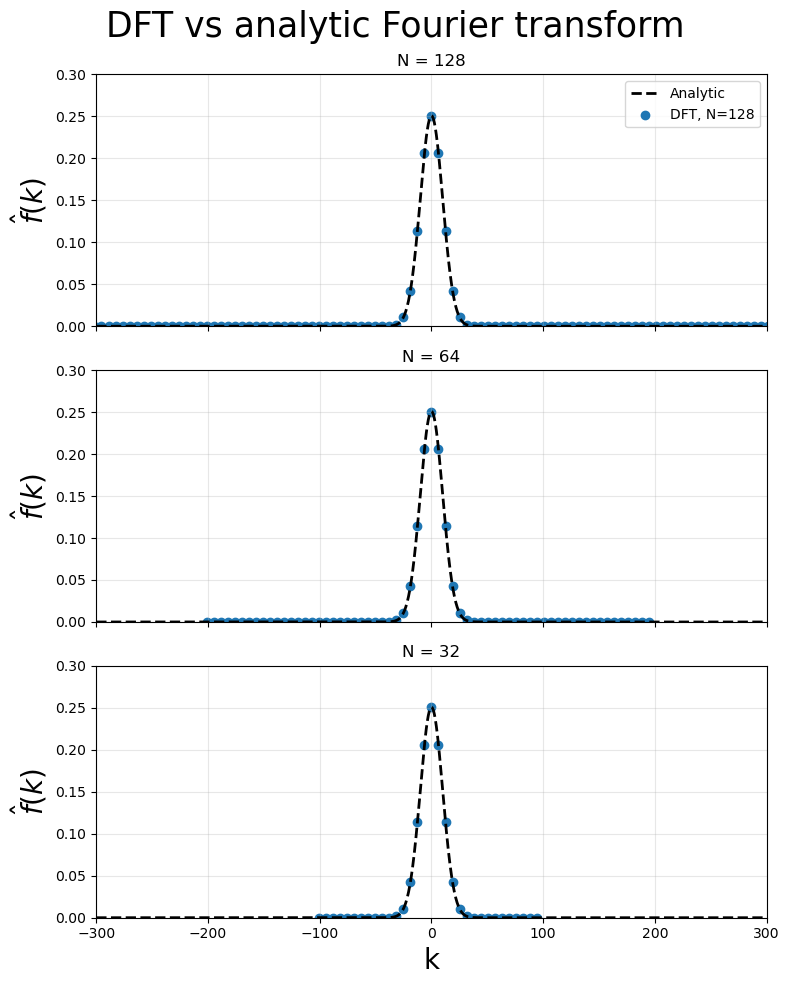

In [31]:
fig, axes = plt.subplots(len(N_values), 1, figsize=(8, 10), sharex=True, sharey=True)

k_value = np.linspace(-300, 300, 2000)
F_analy = np.abs(F_analytic(k_value))

for ax, N in zip(axes, N_values):
    x = np.linspace(0.0, L, N, endpoint=False)
    dx = x[1] - x[0]
    xn = f(x)

    Xk = dft_forward(xn)
    k = k_grid(N, L)
    F_num = dx * Xk

    idx = np.argsort(k)

    ax.plot(k_value, F_analy, 'k--', linewidth=2, label='Analytic')
    ax.scatter(k[idx], np.abs(F_num[idx]), label=f'DFT, N={N}')

    ax.set_ylabel(r'$\hat{f}(k)$', fontsize = 20)
    ax.set_title(f'N = {N}')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('k', fontsize = 20)

axes[0].set_xlim(-300, 300)
axes[0].set_ylim(0, 0.3)
axes[0].legend()

plt.suptitle('DFT vs analytic Fourier transform', y=0.98, fontsize = 25)
plt.tight_layout()
plt.show()

Text(0.02, 0.5, 'Xk')

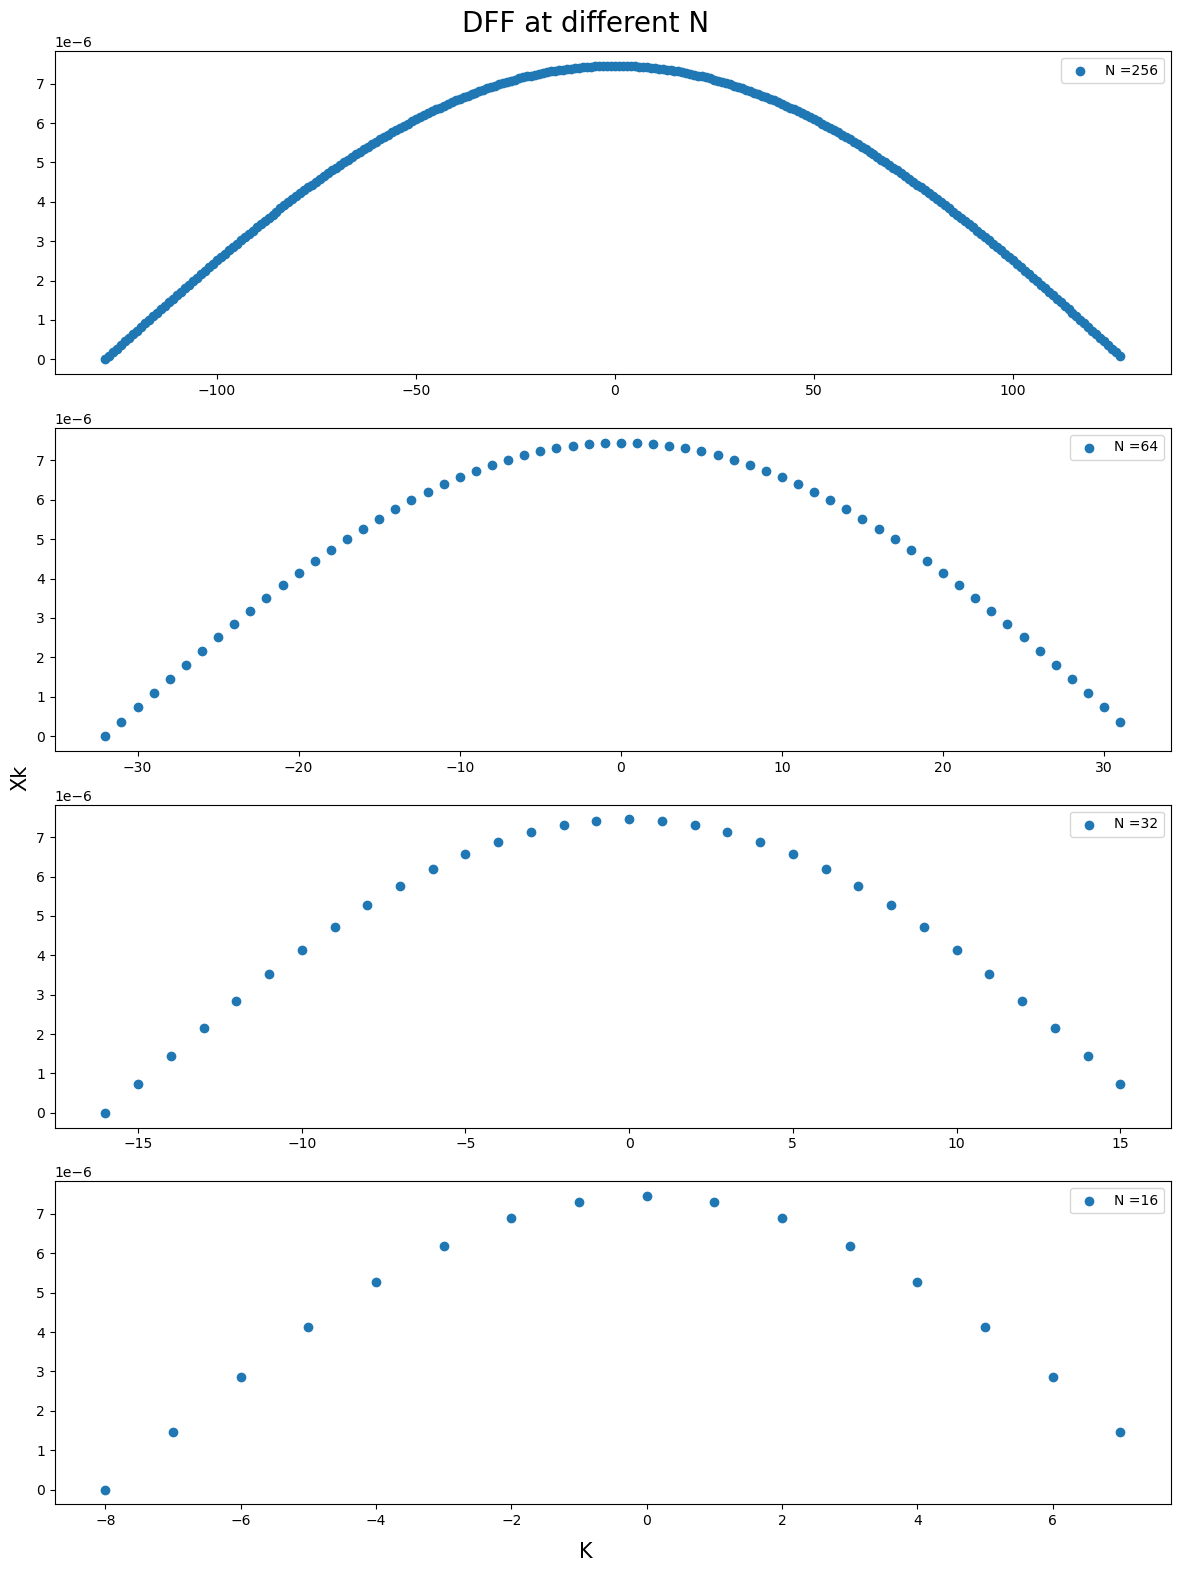

In [8]:
N_list = [256,64,32,16]
L = 1
fig,ax = plt.subplots(len(N_list),figsize = (12,4*(len(N_list))))

for i,N in enumerate(N_list):
    k_array = scipy.fft.fftfreq(N, L/N)
    n_array = np.linspace(0,N-1,N)
    Xk_array = eq_2(k_array,n_array,N,L)
    ax[i].scatter (k_array,Xk_array, label = r"N =" + str(N))
    ax[i].legend()
    

fig.suptitle('DFF at different N',fontsize = "20")
fig.supxlabel('K',fontsize = "15")
fig.supylabel('Xk',fontsize = "15")

In [4]:
k_array

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7., -8., -7., -6., -5., -4.,
       -3., -2., -1.])

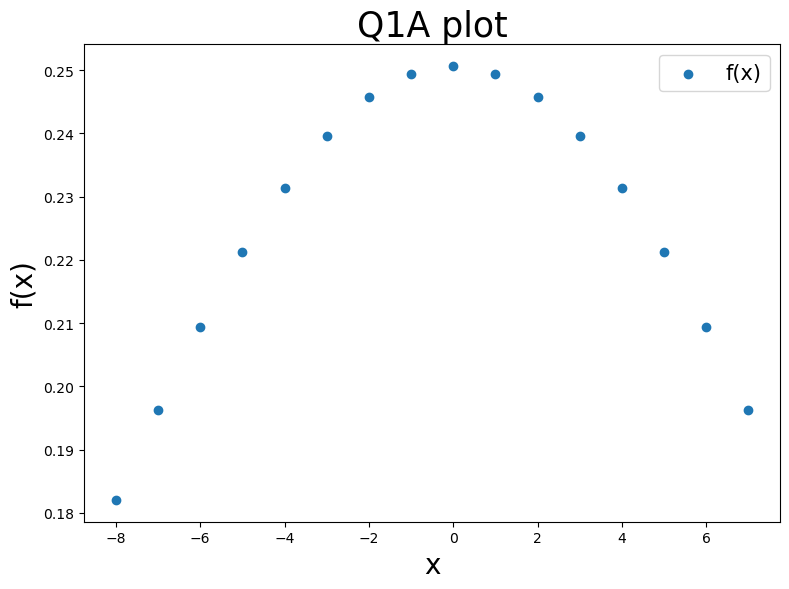

In [5]:
x_array = np.linspace(0,1,100)
fx_array = eq_b(x_array)

plt.rcParams["figure.figsize"] = (8,6)

plt.scatter(k_array,eq_1(k_array), label = "f(x)")


plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
#plt.ylim(-75,75)
#plt.xlim(0,2*np.pi)
plt.title("Q1A plot",size= 25)
plt.legend(fontsize = 15);